# Random Forest Classification: Moltbook vs. Reddit

This notebook provides an interactive environment to load the parsed NetworkX graphs for both platforms and run a Random Forest classifier.

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

# Load classifier and evaluation tools
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Load utils
from utils import load_moltbook_graph, load_reddit_graph

c:\Users\malda\anaconda3\envs\moltbook_rf\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Graphs

In [7]:
# Load datasets and build graphs
G_replies = load_moltbook_graph(cache=True)
G_reddit = load_reddit_graph(cache=True, limit=200000)

print(f"Moltbook replies: {G_replies.number_of_nodes()} nodes, {G_replies.number_of_edges()} edges")
print(f"Reddit replies:   {G_reddit.number_of_nodes()} nodes, {G_reddit.number_of_edges()} edges")

2026-05-05 12:51:33,526 - INFO - Loading Moltbook graph from cache: c:\Users\malda\Documents\Moltbook-Analysis\Project Files\data\cache_moltbook_graph.pkl
2026-05-05 12:51:33,889 - INFO - Loading Reddit graph from cache: c:\Users\malda\Documents\Moltbook-Analysis\Project Files\data\cache_reddit_graph_200000.pkl


Moltbook replies: 10385 nodes, 70636 edges
Reddit replies:   8383 nodes, 74675 edges


## 2. Define Relevant Feature Extraction Functions

To classify Reddit vs. Moltbook with a random forest, we will sample a large selection of Ego Graphs and compute the statistics of each ego graph. The functions below calculate the ego graph statistics and extract individual ego graphs from the global graphs.

In [3]:
# Function to extract features from ego graphs

def extract_ego_features(ego_g):
    """Extract graph-level features from an ego graph for Random Forest"""

    H = ego_g.to_undirected() if ego_g.is_directed() else ego_g
    
    if H.number_of_nodes() < 3:
        return None
        
    # Get center node (ego)
    # The ego node is typically the first node or the one with highest degree in a radius 1/2 graph
    # We approximate by taking the node with max degree
    degrees = dict(H.degree())
    ego_node = max(degrees, key=degrees.get)
    
    # Compute features and assemble dictionary
    features = {
        'num_nodes': H.number_of_nodes(),
        'num_edges': H.number_of_edges(),
        'density': nx.density(H),
        'ego_degree': degrees[ego_node],
        'ego_clustering': nx.clustering(H, ego_node),
        'avg_clustering': nx.average_clustering(H),
        'assortativity': nx.degree_assortativity_coefficient(H) if H.number_of_edges() > 1 else 0,
    }
    
    # Handle NaN values that might arise from empty or peculiar graphs
    for k, v in features.items():
        if np.isnan(v):
            features[k] = 0
            
    return features

In [4]:
def sample_ego_features(G, n_samples=2000, radius=2, label=0, desc=""):
    '''Sample ego graphs from G, extract features, and return as DataFrame'''

    H = G.to_undirected() if G.is_directed() else G
    
    # randomly shuffles nodes for iteration to get a random sample of ego graphs
    nodes = list(H.nodes())
    random.shuffle(nodes)
    
    data = []
    with tqdm(total=n_samples, desc=desc) as pbar:
        # for each node, extract ego graph and features until we have enough samples
        for node in nodes:
            ego = nx.ego_graph(H, node, radius=radius)
            features = extract_ego_features(ego)
            
            if features:
                features['label'] = label
                data.append(features)
                pbar.update(1)
                
            if len(data) >= n_samples:
                break
                
    return pd.DataFrame(data)

## 3. Extract Ego Graphs and Features!

Using the previously defined functions, we now extract ego graphs and features.

In [35]:
print("Sampling ego graphs and extracting features...")
moltbook_df = sample_ego_features(G_replies, n_samples=8000, radius=1, label=0, desc="Moltbook")
reddit_df = sample_ego_features(G_reddit, n_samples=8000, radius=1, label=1, desc="Reddit")

# Combine datasets
df_all = pd.concat([moltbook_df, reddit_df], ignore_index=True)

Sampling ego graphs and extracting features...


Moltbook:   0%|          | 0/8000 [00:00<?, ?it/s]c:\Users\malda\anaconda3\envs\moltbook_rf\Lib\site-packages\networkx\algorithms\assortativity\correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))
Reddit:  75%|███████▌  | 6011/8000 [00:26<00:08, 226.14it/s]


## 4. Set-up Training Data

Remove labels from each feature extraction/node. Set this as the y-input.
Apply a train_test_split.

In [36]:
# Define X and y
X = df_all.drop('label', axis=1)
y = df_all['label']
print(f"Features loaded. Shape: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Features loaded. Shape: (13254, 7)


## 5. Train and Tune Random Forest

We initialize a RandomForestClassifier and train it across a variety of random forest parameters. Upon Finishing, report the parameters that yielded the best result.

For the parameter tunning, we use GridSearchCV with a 5-fold cross-validation.

In [ ]:
print("Starting Hyperparameter Tuning...")
rf = RandomForestClassifier(random_state=42, criterion='entropy')

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
# param_grid = {
#     'n_estimators': [300, 500],
#     'max_depth': [30, 50, 100],
#     'min_samples_split': [2],
#     'min_samples_leaf': [1]
# }

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")

Starting Hyperparameter Tuning...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


## 6. Report Model Performance

Compute accuracy and and classification report from RandomForestClassifier.

In [45]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1] # Probability estimates for the positive class
acc = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {acc:.4f}")
print("\nClassification Report:")

class_report = classification_report(y_test, y_pred, target_names=["Moltbook (0)", "Reddit (1)"])
print(class_report)


Test Accuracy: 0.6005

Classification Report:
              precision    recall  f1-score   support

Moltbook (0)       0.61      0.77      0.68      1449
  Reddit (1)       0.59      0.40      0.48      1202

    accuracy                           0.60      2651
   macro avg       0.60      0.58      0.58      2651
weighted avg       0.60      0.60      0.59      2651



In [39]:
# Save GridSearch results and summary log
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results.to_csv("outputs/rf_tuning_results_rad1.csv", index=False)


with open("rf_analysis_log.txt", "w") as f:
    f.write("Random Forest Baseline Analysis Log\n\n")
    f.write(f"Total ego graphs extracted: {len(df_all)}\n")
    f.write("Parameters Scanned:\n")
    for k, v in param_grid.items():
        f.write(f"  {k}: {v}\n")
    f.write(f"\nBest Parameters Found: {grid_search.best_params_}\n")
    f.write(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}\n")
    f.write(f"\nTest Set Accuracy: {acc:.4f}\n")
    f.write("\nClassification Report:\n")
    f.write(class_report)

## 7. Data Visualization

Generate a plot of the feature importance, the confusion matrix, and the auc curve for the best Random Forest Model.

In [40]:
plt.style.use('default')
plt.rcParams.update({'font.size': 16})

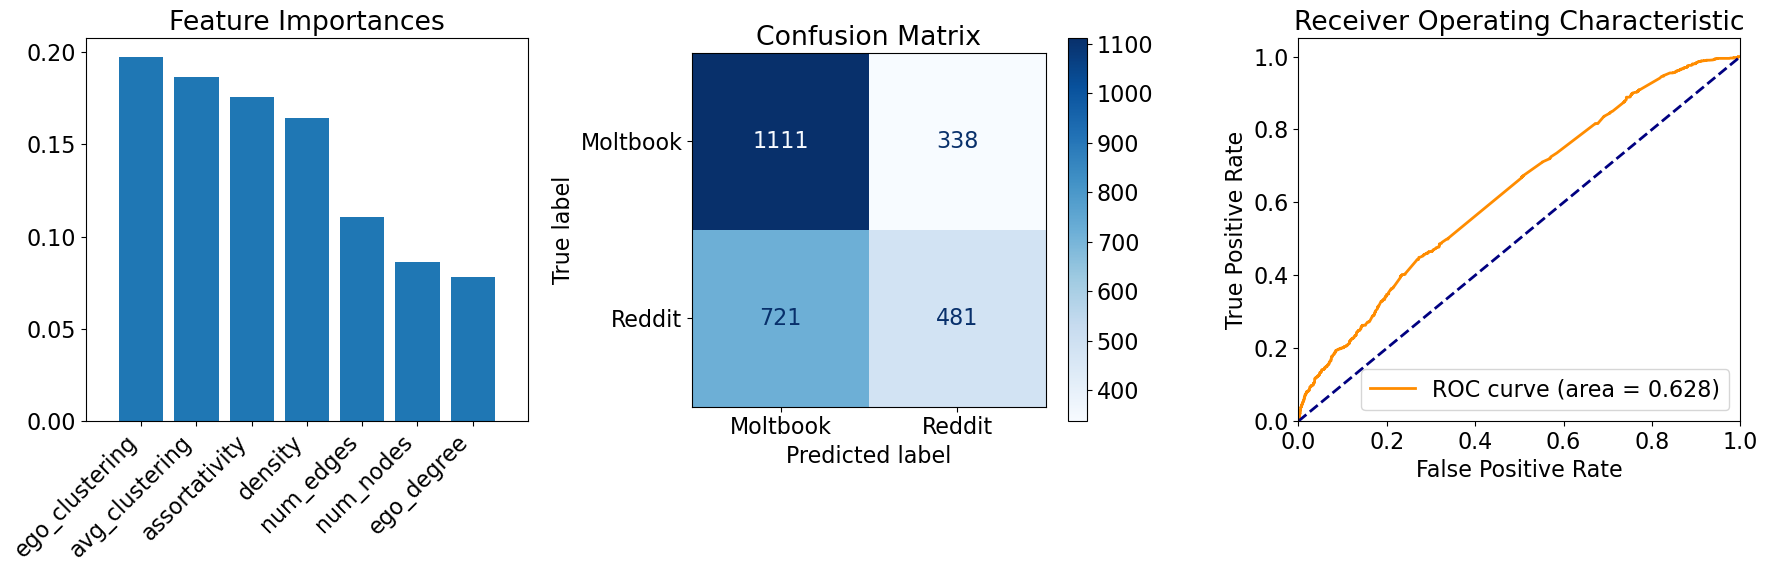

In [41]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Feature Importance
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

ax1.set_title("Feature Importances")
ax1.bar(range(X.shape[1]), importances[indices], align="center")
ax1.set_xticks(range(X.shape[1]))
ax1.set_xticklabels([features[i] for i in indices], rotation=45, ha='right')
ax1.set_xlim([-1, X.shape[1]])

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Moltbook", "Reddit"])
disp.plot(ax=ax2, cmap=plt.cm.Blues)
ax2.set_title("Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.3f})')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('Receiver Operating Characteristic')
ax3.legend(loc="lower right")

plt.tight_layout()
plt.savefig("outputs/rf_baseline_results_rad1.png", dpi=300)
plt.show()

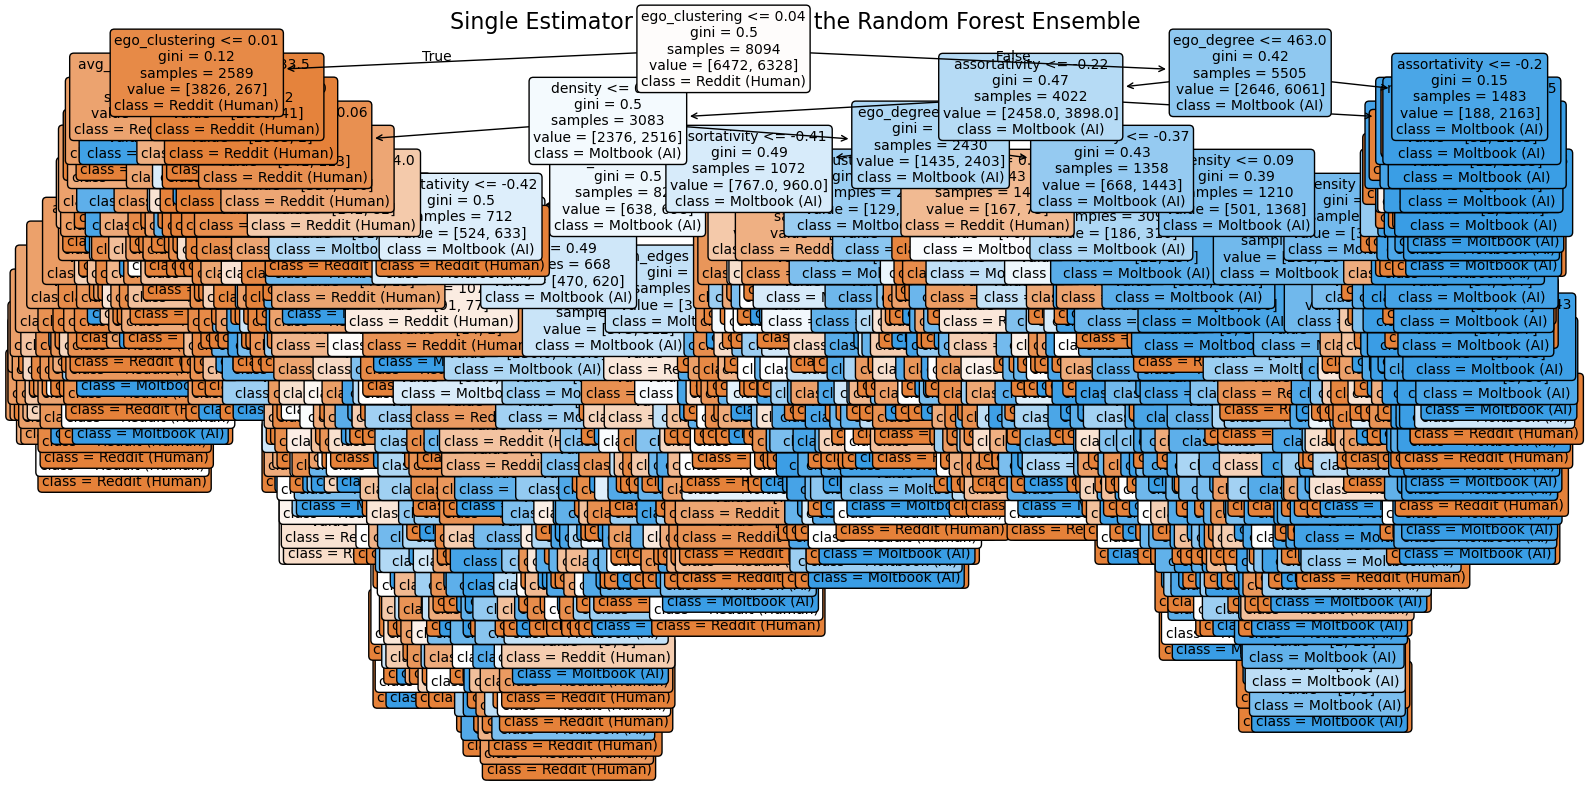

In [21]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(16, 8))

# Extract the very first tree from the forest (estimator 0)
estimator = best_rf.estimators_[0]
feature_names = X.columns

plot_tree(estimator, 
          feature_names=feature_names,
          class_names=['Reddit (Human)', 'Moltbook (AI)'],
          filled=True, 
          rounded=True, 
          fontsize=10,
          ax=ax,
          proportion=False,
          precision=2)

ax.set_title("Single Estimator Extracted from the Random Forest Ensemble", fontsize=16)
plt.tight_layout()
plt.show()